Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name and collaborators below: 


In [63]:
NAME = "Robert van der Leeuw"
STUDENT_NUMBER = "s1190941"

### Important: When handing in your homework:
- Hand in the notebook named as follows: Studentname_snumber.ipynb
- If you find any mistakes/have suggestions/like to complain about the material, please e-mail Emma at `emma.gerritse@ru.nl`
- Do not remove any cells in the notebook, as it might break the auto-grader
- When using platforms other than Jupyter Labs to make your assignments, it might add additional metadata to the Jupyter Notebook file, which will break the autograder. To prevent this, please copy the answers back into the original notebook.
- It is okay to use VS Code or PyCharm. If you want to be sure if your favorite editor is allowed, please ask your TA for help, or check manually. Google Colab is known to add extra metadata, so please do not use this, or copy back the cells to an empty file.  
- Only type your answers in places where asked.
- Before handing in your Notebook, make sure to run `Kernel > Restart Kernel and Run All Cells` one more time, and make sure it runs to the last cell without raising any errors. 

To make sure your answers work correctly, please make sure to use the variable names as given in the assignment. This will look like:

```
    some_variablename = None

    # YOUR CODE HERE
    raise NotImplementedError()
```
You have to remove the `raise NotImplementedError()` and answer the assignment as follows:

```
    some_variablename = None
    # YOUR CODE HERE
    your_code
    more_code
    some_variable = some_results
```

Not using the specified variable names may result in reduced points.

---

# Assignment 2: Logistic regression, train/test split, evaluation

## Deadline: September 29th, 23:59

In this assignment, you will learn: 
 - How to implement logistic regression with stochastic batch-wise gradient descent
 - Different strategies for imputing data
 - More tactics for visualization
 - How to compute Accuracy, ROC, and AUC
 - How to use packages for logistic regression and metrics.

Again, in case you get stuck anywhere, you can always try continuing to the next exercise. 

Last time, we used the Penguin dataset to predict the weight of the penguin. Now, we will predict the species of the penguin based on different features. 
In case you don't have the CSV ready anymore, download it here. 

In [2]:
#!curl -o penguin.csv https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv

To make sure the rest of this part of the assignment goes smoothly, we will pre-process the penguin dataset for you.


If you want to learn more about the MinMaxScaler, check out the [documentation here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) . We will learn more about this in later assignments. 

In [64]:
import numpy as np
import pandas as pd
penguins = pd.read_csv("penguin.csv")
penguins_processed = penguins.dropna().copy()

To do a bit more data exploration, we will look at a [Grid matrix](https://holoviews.org/gallery/demos/bokeh/iris_density_grid.html) ;

This is an easy way to plot multiple features. 
Look through this scatter matrix and think:

- Which penguin species is easiest to predict? (Adelie, Chinstrap, or Gentoo)?
- Which feature is best for predicting this? (Bill length, Bill depth, Flipper length, Body mass?)


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
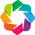

:GridMatrix   [X,Y]
   :Overlay
      .NdOverlay.I  :NdOverlay   [species]
         :Distribution   [flipper_length_mm]   (Density)
      .NdOverlay.II :NdOverlay   [species]
         :Histogram   [flipper_length_mm]   (Count)

In [65]:
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

import holoviews as hv
from holoviews import opts
from holoviews.operation import gridmatrix

hv.extension('bokeh')
hv.renderer("bokeh").webgl = False

ds = hv.Dataset(
    penguins_processed,
    kdims=features,
    vdims=["species"],
).groupby('species').overlay()

density_grid = gridmatrix(ds, diagonal_type=hv.Distribution, chart_type=hv.Bivariate)
point_grid = gridmatrix(ds, chart_type=hv.Points)

(density_grid * point_grid).opts(
    opts.Bivariate(bandwidth=0.5, cmap=hv.Cycle(values=['Blues', 'Reds', 'Oranges'])),
    opts.Points(size=2, alpha=0.5, tools = ['hover']),
    opts.NdOverlay(batched=False))


### Exercise 1.1


Judging from the plots above, the easiest species of penguins to classify is `Gentoo` (why?). Thus, we will classify 'Gentoo' and 'Not Gentoo'. 

Using Pandas, it's easy to add a column. Take a look here:
https://pandas.pydata.org/docs/getting_started/intro_tutorials/05_add_columns.html 
and here:
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.apply.html

First, make the NumPy array X using the feature `bill_depth_mm`, resulting in an `(333,1)` shaped array.

Then, add a column 'Gentoo' to the Penguin dataframe, which is `True` for Gentoo penguins and `False` for the other Penguins.
Create the numpy array `y` shaped `(333,)` where the value is '1' for a Gentoo penguin and '0' for a not-Gentoo penguin.





In [68]:
X = penguins_processed["bill_depth_mm"].to_numpy().reshape(-1, 1)
penguins_processed["Gentoo"] = penguins_processed["species"] == "Gentoo"
y = penguins_processed["Gentoo"].to_numpy()

In [69]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 1.2
Last time, we did not use a train-test split, to simplify the assignment a little bit. 
Starting this assignment, we will _always_ do a train-test split! 
Use the documentation of [SK learn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) to create a train-test split of the penguins. 


Make a train test split with the specified variable names, the specified random seed, and test size.

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# We will scale the data for you, to make your life a bit easier
# Note that we fit the scaler on the train data and then fit it on the test data
# Otherwise we would leak data
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 1.3

Let's implement the formula of the logistic function, as seen below:

$$ h(x) = \frac{1}{1+e^{-(x\cdot w + b)}} $$

Similar to the function you made last time for linear regression, make a function that, given a matrix X of shape (N,m), a weight matrix of shape (m,1), and a float value bias, and make sure the resulting vector has _the same shape as y_ .

[Numpy Divide](https://numpy.org/doc/stable/reference/generated/numpy.divide.html) and [Numpy Exp](https://numpy.org/doc/stable/reference/generated/numpy.exp.html) might be useful. 

In [71]:
def evaluate_set(X, weight, bias):
    return np.divide(1, (1 + np.exp(-(weight @ X.T + bias))))

In [10]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 1.4 

Run the following two cells to test if you implemented your function correctly.

If correct, all predictions should be somewhat accurate. 

If you want, you can edit the values for `w` and `b` to see what happens to the logistic function.

Get a feeling for what happens when `w` becomes larger/smaller, and when `b` becomes larger/smaller.

Which of these functions do you feel is most _likely_ to predict y_test?

In [72]:
preds = [
    evaluate_set(X_test, np.array([-21]), 8),
    evaluate_set(X_test, np.array([-19]), 8),
    evaluate_set(X_test, np.array([-21]), 6),
    evaluate_set(X_test, np.array([-21]), 10),
    evaluate_set(X_test, np.array([-23]), 8),
]

In [73]:
scatter = hv.Scatter((X_test, y_test), label = 'Ground truth').opts(size = 5,
    width=800,
    height=800,
    tools = ['hover'])

for i, pred in enumerate(preds):
    scatter = scatter * hv.Scatter((X_test, pred), label = f'Prediction {i}').opts(size = 5, marker = '+', tools = ['hover'])

scatter    

:Overlay
   .Scatter.Ground_truth :Scatter   [x]   (y)
   .Scatter.Prediction_0 :Scatter   [x]   (y)
   .Scatter.Prediction_1 :Scatter   [x]   (y)
   .Scatter.Prediction_2 :Scatter   [x]   (y)
   .Scatter.Prediction_3 :Scatter   [x]   (y)
   .Scatter.Prediction_4 :Scatter   [x]   (y)

Great! Now let's figure out how well we did. For that, we are going to use the _Log likelihood_ .

$$\text{Log Likelihood} (\hat{y}, y) = \sum_{i=1}^n y^{(i)}\log (h(x^{(i)})) + (1-y^{(i)}) \log(1-h(x^{(i)}))$$

In [74]:
def log_likelihood(pred, y):
    positives = np.multiply(y, np.log(pred))
    negatives = np.multiply(1 - y, np.log(1 - pred))
    return np.sum(positives + negatives)

In [75]:
# Let's explore all the log likelihoods of the predictions we made above:
# Does this agree with which functions you thought were most likely?
for pred in preds:
    print(log_likelihood(pred, y_test))

-17.572975608846544
-18.340552065105864
-27.801382129528882
-25.570697276383733
-19.91011614375751


### Exercise 1.5

Create the gradient descent function. It should be similar to the one you made last week.

Remember that last time, we made a separate function called `gradient`. You can either do that again, or just make the update rule in one go.
The update rules should be, for learning rate $\alpha$


$$ w := w + \alpha \sum_i ( y^{(i)} - h_w(x^{(i)}))\cdot x^{(i)} $$


$$ b := b + \alpha \sum_i ( y^{(i)} - h_w(x^{(i)})) $$


In [76]:
def gradient_descent(x, y, lr, steps):
    N, dim = x.shape
    weights = np.ones((dim))
    bias = 0
    all_weights = []
    all_bias = []
    for i in range(steps):
        pred = evaluate_set(x, weights, bias)
        
        weights += lr * (y - pred) @ x
        bias += lr * np.sum(y - pred)

        all_weights.append(weights[0])
        all_bias.append(bias)
    return weights, bias, all_weights, all_bias

### Exercise 1.6

Play around with the values of `learning_rate` and `steps` until you get an llh somewhat close to 0.
Use the plots below to get more insights into your predictions. 

(_note that you can just remove the `YOUR CODE HERE` part and change the first two lines_)

In [77]:
learning_rate = 0.18
steps = 100

gw_weights, gw_bias, weightvec, biasvec = gradient_descent(
    X_train, y_train, learning_rate, steps
)
print(f" Weights: {gw_weights}, bias: , {gw_bias}")
pred = evaluate_set(X_test, gw_weights, gw_bias)
llh = log_likelihood(pred, y_test)
print(f"Log likelihood:  {llh}")

 Weights: [-31.30954945], bias: , 12.0779114340496
Log likelihood:  -19.800152352951518


In [17]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

Let's plot the prediction to see if our prediction makes sense:

In [83]:
X_test.flatten().shape

(84,)

In [84]:
scatter = hv.Scatter((X_test.flatten(), y_test), label = 'Ground truth').opts(width=800,height=800,tools = ['hover'])
scatter_pred = hv.Scatter((X_test.flatten(), pred), label = 'Prediction')

scatter * scatter_pred

TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

:Overlay
   .Scatter.Ground_truth :Scatter   [x]   (y)
   .Scatter.Prediction   :Scatter   [x]   (y)

## 1.6b
Inspect the path of gradient descent

Note, if you have very large paths for weightvec and biasvec, this might crash your notebook while plotting

In case this happens, increase `take_every_kth` to a higher value (for example 10 or 100)


`weightvec = weightvec[::take_every_kth]` takes every kth element of weightvec.

In [19]:
# Use this plot to inspect the path of the gradient descent. Try investigating the path of the weight/bias

import plotly.graph_objects as go

# Increase this value of your plot crashes
take_every_kth = 1

# You can change the first two values in x_plot and y_plot below to change the range of the x and y axis.
weights_plot = np.linspace(-35, 5, 130)
bias_plot = np.linspace(-10, 10, 130)

# Next we will create our mesh grid, this will create two 2-D arrays. One contains the x-value,
# and one contains the y-value
ww, bb = np.meshgrid(weights_plot, bias_plot)


# np.vectorize is very similar to a map in functional programming, and allows us
# to be able to use any function on an entire array
@np.vectorize
def vectorized_MLL(weights, bias):
    return log_likelihood(evaluate_set(X_train, np.array([weights]), bias), y_train)

MLL = vectorized_MLL(ww, bb)

image = hv.Image(
    (weights_plot, bias_plot, MLL),
    kdims=["Weight", "Bias"],
    vdims=["MLL"],
)

image.opts(
    cmap="Plasma",
    logz=True,
    colorbar=True,
    width=800,
    height=800,
    xlabel="Weight",
    ylabel="Bias",
    tools=["hover"]

)

contours = hv.operation.contours(image, levels=15)#.opts(logz=True)
image * contours

:Overlay
   .Image.I    :Image   [Weight,Bias]   (MLL)
   .Contours.I :Contours   [Weight,Bias]   (MLL)

### Exercise 1.7

Let's add batched stochastic gradient descent to our toolkit. 
For this, we will add an extra loop inside our loop, where we will compute the gradients over small random parts of the datasets, called batches.

We will use the [np.random.permutation](https://numpy.org/doc/stable/reference/random/generated/numpy.random.permutation.html) function to shuffle the indexes.

Recall that you can also index np arrays using other numpy arrays, 

so if `A = np.array([3,6,9,12]), B = np.array([1,3])`
`A[B] = [6,12]`


Use this to make two arrays x_mini and y_mini with the perm indexes, and then compute the gradient like you did before.

In [20]:
def stochastic_gradient_descent(x, y, lr, steps, batch_size):
    N, dim = x.shape
    weights = np.ones((dim))
    bias = 0
    weightvec = []
    biasvec = []
    for i in range(steps):
        permutation = np.random.permutation(N)
        for i in range(0, N, batch_size):
            perm = permutation[i : i + batch_size]
            
            x_mini, y_mini = x[perm], y[perm]

            pred = evaluate_set(x_mini, weights, bias)
            
            weights += lr * (y_mini - pred) @ x_mini
            bias += lr * np.sum(y_mini - pred)
            
            weightvec.append(weights[0])
            biasvec.append(bias)
    return weights, bias, weightvec, biasvec

### Exercise 1.8

Play around with the values of `learning_rate`,  `steps` and `batch_size` until you get an acceptable answer.

Use the plots below to get more insights into your predictions. 

(_note that you can just remove the `YOUR CODE HERE` part and change the first three lines_)

In [21]:
learning_rate = 0.1
steps = 50
batch_size = 10

(
    gw_weights_stoch,
    gw_bias_stoch,
    weightvec_stoch,
    biasvec_stoch,
) = stochastic_gradient_descent(X_train, y_train, learning_rate, steps, batch_size)
print(gw_weights_stoch, gw_bias_stoch)

print(f" Weights: {gw_weights}, bias: , {gw_bias}")
pred = evaluate_set(X_test, gw_weights_stoch, gw_bias_stoch)
llh = log_likelihood(pred, y_test)
print(f"Log likelihood:  {llh}")

[-16.84113689] 6.282107003402119
 Weights: [-31.30954945], bias: , 12.0779114340496
Log likelihood:  -17.541008762745083


In [22]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

In [23]:
# Use this plot to see if your prediction makes sense
scatter = hv.Scatter((X_test, y_test), label = 'Ground truth').opts(width=800,height=800,tools = ['hover'])
scatter_pred = hv.Scatter((X_test, pred), label = 'Prediction')

scatter * scatter_pred

TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

:Overlay
   .Scatter.Ground_truth :Scatter   [x]   (y)
   .Scatter.Prediction   :Scatter   [x]   (y)

In [24]:
# Use this plot to inspect the bath of the gradient descent. Try investigating the path of the weight/bias
# Can you see that the gradient path is more wobbly here? Try changing the values of the batch size

# Again, increase this number in case your plot crashes
take_every_kth = 1


trace = hv.Scatter((weightvec_stoch[::take_every_kth], biasvec_stoch[::take_every_kth]), 
                   label = 'Gradient descent').opts(width=800,height=800,tools = ['hover'])

image * contours * trace


:Overlay
   .Image.I                  :Image   [Weight,Bias]   (MLL)
   .Contours.I               :Contours   [Weight,Bias]   (MLL)
   .Scatter.Gradient_descent :Scatter   [x]   (y)

# Part for WEEK 4:

Note, this part is to be done after you have attended the 4th lecture. You can work ahead, but we can't promise that the TA's can already help you with this part. If you get stuck in Exercise 2.1, try continuing to Exercise 2.2. 

### Exercise 2.1.1


## Evaluation

Now, we will compute some evaluations. Based on a certain threshold, we'll make functions for the true positives, false positives, true negatives, and false negatives. 

Tip: we can use some Numpy functionality to compare two arrays.

First of all, we can compare all elements of a numpy array using Boolean operators. For example
`np.array([0 , 1])>0.5` will return `array([False, True])`

Next, we can elementwise compare two NumPy arrays using [np.equal](https://numpy.org/doc/stable/reference/generated/numpy.equal.html).

Note that `True` and `False` are the same as `1` and `0`,

so `np.equal(np.array([0,1,0,1]), np.array([False, True, True, False]))`

will result in `array([ True,  True, False, False])`

You can use the functions `np.logical_and`, `np.logical_or`, `np.logical_not` and `np.logical_xor` in a similar way. 

Next, if you want to compute the number of times `True` is used in an array, we can just use the `np.sum`.

So `np.sum(np.array([True, True, False, False]))` will result in `2`. 

Using this, make functions for the following metrics: 

In [25]:
### Return the number of true positives given a certain threshold
def true_positive(pred, y, threshold=0.5):
    return np.sum(np.logical_and((pred >= threshold), y))

In [26]:
def true_negative(pred, y, threshold=0.5):
    return np.sum(np.logical_and(pred < threshold, np.logical_not(y)))

In [27]:
### Return the number of false positives given a certain threshold


def false_positive(pred, y, threshold=0.5):
    return np.sum(np.logical_and((pred >= threshold), np.logical_not(y)))

In [28]:
### Return the number of false negatives given a certain threshold


def false_negative(pred, y, threshold=0.5):
    return np.sum(np.logical_and(pred < threshold, y))

In [29]:
### Use this cell to test:
### NOTE: FP+FN+TP+TN should be equal to total, so for this example the total should add up to 6
predictions = np.array([0.1,    0.3,   0.4,  0.5,  0.8,   0.9])
ground_truth = np.array([False, False, True, True, False, True])

threshold = 0.45
print(true_positive(predictions, ground_truth, threshold))
print(true_negative(predictions, ground_truth, threshold))
print(false_positive(predictions, ground_truth, threshold))
print(false_negative(predictions, ground_truth, threshold))

2
2
1
1


In [30]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.1.2

Now we can use these to compute the following other metrics. Reuse the functions you made above:

$$     \texttt{True Positive Rate} = \frac{\texttt{TP}}{\texttt{TP+FN}} $$
$$     \texttt{False Positive Rate} = \frac{\texttt{FP}}{\texttt{FP+TN}} $$



In [31]:
def true_positive_rate(pred, y, threshold=0.5):
    tp = true_positive(pred, y, threshold)
    fn = false_negative(pred, y, threshold)
    return tp / (tp + fn)

In [32]:
def false_positive_rate(pred, y, threshold=0.5):
    fp = false_positive(pred, y, threshold)
    tn = true_negative(pred, y, threshold)
    return fp / (fp + tn)

In [33]:
## Use this cell to inspect your answer

predictions = np.array([0.1, 0.3, 0.4, 0.5, 0.8, 0.85, 0.89, 0.9])
ground_truth = np.array([False, False, True, True, False, True, True, True])

threshold = 0.5
print(true_positive_rate(predictions, ground_truth, threshold))
print(false_positive_rate(predictions, ground_truth, threshold))

0.8
0.3333333333333333


In [34]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.1.3

Next, we will implement the ROC curve: 

- Iterate through all the thresholds
- Compute the TPR and FPR for those thresholds
- Append the values to the arrays `tpr` and `fpr`

In [35]:
def ROC(predictions, true):
    tpr = []
    fpr = []

    for threshold in predictions:
        tpr.append(true_positive_rate(predictions, true, threshold))
        fpr.append(false_positive_rate(predictions, true, threshold))
        
    return tpr, fpr

In [36]:
# Use this cell to test the code above.

predictions = np.array([0.1, 0.3, 0.4, 0.5, 0.8, 0.85, 0.89, 0.9])
true = np.array([False, False, True, True, False, True, True, True])

roc_tpr, roc_fpr = ROC(predictions, true)

print(roc_tpr, roc_fpr)

[np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.8), np.float64(0.6), np.float64(0.6), np.float64(0.4), np.float64(0.2)] [np.float64(1.0), np.float64(0.6666666666666666), np.float64(0.3333333333333333), np.float64(0.3333333333333333), np.float64(0.3333333333333333), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


In [37]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.1.4

Plot the resulting ROC, where you have the FPR on the x-axis and the TPR on the y-axis.

Hint: All plotted points should be above the line $y=x$.

Hint: When using Holoviews, try to reuse the plotting code given in earlier exercises, or check the documentation examples over [here](https://holoviews.org/reference/elements/bokeh/Curve.html) . 

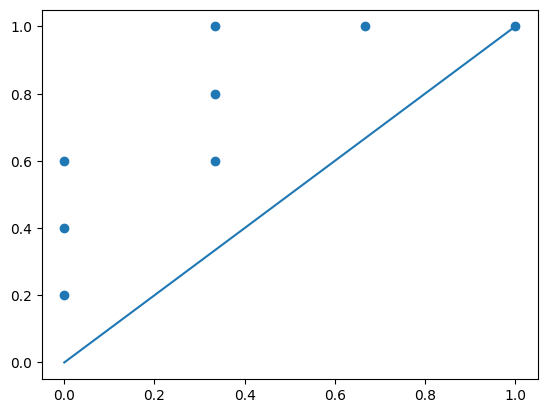

In [38]:
from matplotlib import pyplot as plt
plt.scatter(roc_fpr, roc_tpr)
plt.plot([0, 1])

### Exercise 2.1.5
Compute, by hand, the value of the area under curve, and store the value in the variable AUC:
Your value should be a value between 0 and 1.

Hint: Divide the square into smaller squares.

In [39]:
AUC = 0.2 * (0.6 + 1 + 1)
AUC

0.52

In [40]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.2 Using the common packages

Now that we have a better idea of how evaluation metrics work, we will go back to making some predictions on the Penguin dataset. 

Take another look at the penguin dataset. In exercise 1, we just discarded everything which has a NaN value.
For having a machine learning model in production, that would not generalize very well. 

We will again do a little bit of the data processing for you:


In [41]:
# Since we edited it before, let's load it again
penguins = pd.read_csv("penguin.csv")

features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
X = penguins[features].to_numpy()
predict_type = "Adelie"

penguins[predict_type] = penguins["species"] == predict_type
y = penguins[predict_type].to_numpy().astype(int)

random_size = 1
test_size = 0.25

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=1
)

### Exercise 2.2.1

Find if there are NaN values in X_train or X_test. You can use for example [isnan](https://numpy.org/doc/stable/reference/generated/numpy.isnan.html)  and [numpy any](https://numpy.org/doc/stable/reference/generated/numpy.any.html)

In [42]:
nans_in_train = np.any(np.isnan(X_train))
nans_in_test = np.any(np.isnan(X_test))

In [43]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.2.2 

Use the [Scikit module for logistic regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) to train a model on 3 different training sets:


`X_zero` : all nan values are substituted by 0, using all columns of X_train. 

Find a strategy how to impute all nan values by 0. 

`X_mean`: all nan values are substituted by the mean, using all columns of X_train. 

Read more about imputing with the mean value here: [imputing strategies](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) . 


`X_bill_length` : only train on the zeroth column, which is the bill length. Don't forget to then also only test on the zeroth column of the testset. Use one of the previous two imputation methods. 


For all three of these, compute the [Accuracy](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) and print it.


In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer

In [45]:
imp = SimpleImputer(strategy="constant", fill_value=0)
imp.fit(X_train, y_train)

X_zero = imp.transform(X_train) # np.nan_to_num(X_train)

clf = LogisticRegression()
clf.fit(X_zero, y_train)

pred_zero = clf.predict(imp.transform(X_test))
acc_zero = accuracy_score(y_test, pred_zero)

print(acc_zero)

0.9883720930232558


In [46]:
imp = SimpleImputer(strategy="mean")
imp.fit(X_train, y_train)

X_mean = imp.transform(X_train)

clf = LogisticRegression()
clf.fit(X_mean, y_train)

pred_mean = clf.predict(imp.transform(X_test))
acc_mean = accuracy_score(y_test, pred_mean)

print(acc_mean)

0.9883720930232558


/nix/store/dz4n1i1slfrfxwd6qds456af10zajgrm-bci-BKI323-env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [47]:
X_bill_length = X_train[:, 0].reshape(-1, 1)

imp = SimpleImputer(strategy="mean")
imp.fit(X_bill_length, y_train)

X_bill_length = imp.transform(X_bill_length)

clf = LogisticRegression()
clf.fit(X_bill_length, y_train)

pred_bill_length = clf.predict(imp.transform(X_test[:, 0].reshape(-1, 1)))
acc_bill_length = accuracy_score(y_test, pred_bill_length)

print(acc_bill_length)

0.9302325581395349


In [48]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 2.2.3

Which of these strategies do you think was best? Which one is the worst? Why?

YOUR ANSWER HERE

### Exercise 2.2.4


Using the `X` we defined in `2.2`, let us use K-fold validation. 

For now, let's just take a look at what this method is doing. 

Run the code below. 
What do the arrays `train_index` and `test_index` represent?

What will be the result of `X[train_index]`?

Type out an answer in the markdown cell below:

In [49]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5)

for i, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index} \n \n")

Fold 0:
  Train: index=[ 69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86
  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104
 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122
 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140
 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158
 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176
 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194
 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212
 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230
 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248
 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265 266
 267 268 269 270 271 272 273 274 275 276 277 278 279 280 281 282 283 284
 285 286 287 288 289 290 291 292 293 294 295 296 297 298 299 300 301 302
 303 304 305 306 307 308 309

YOUR ANSWER HERE

### Exercise 2.2.5

Using one of the imputing strategies you saw before, and using the 5-fold cross validation made in the previous exercise, 
fit the model 5 times on the train folds, evaluate 5 times on the corresponding test folds, and print the accuracy score and model weights (using `clf.coef_`) for every fold. What do you observe? 

In [50]:
# YOUR CODE HERE
raise NotImplementedError()

NotImplementedError: 

### Exercise 2.2.5.b
What do you notice about the accuracy and model weights?

YOUR ANSWER HERE